# Mini-projet : Prédiction des maladies cardiaques à l’aide de la régression logistique

##  Ce que nous allons apprendre

*   Comment gérer des données de santé réelles.
*   Prétraitement des données : Gestion des valeurs manquantes, des variables catégoriques et de l’échelon des caractéristiques.
*   Entraînement d’un modèle de régression logistique pour prédire la présence de maladies cardiaques.
*   Évaluation des performances du modèle en utilisant la précision, la précision, le rappel et le score F1.

##  Outils et bibliothèques requis

*   **Python**
*   **scikit-learn**: Pour l’exploration, l’analyse et la modélisation.
*   **pandas**: Pour la manipulation et l’analyse de données.
*   **matplotlib** et **seaborn**: Pour la visualisation des données.

## 1. Préparation des données

Cette section couvre le chargement du jeu de données, l'analyse exploratoire des données (EDA) et le prétraitement nécessaire pour préparer les données à la modélisation.

### 1.1 Importation des bibliothèques nécessaires

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Toutes les bibliothèques nécessaires ont été importées avec succès!")

Toutes les bibliothèques nécessaires ont été importées avec succès!


### 1.2 Chargement et examen du jeu de données

Nous allons tenter de charger le jeu de données 'Heart Disease UCI'. Si le fichier `heart.csv` n'est pas trouvé, nous générerons un jeu de données factice pour la démonstration.

In [40]:
# Télécharger le fichier ZIP contenant les données
!wget https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip

# Dézipper le fichier pour obtenir heart.csv
!unzip -o "UCI Heart Disease Data.zip"

print("Fichier 'heart.csv' téléchargé et extrait avec succès.")

--2026-06-14 11:47:42--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip [following]
--2026-06-14 11:47:42--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12672 

In [41]:
try:
    df_heart = pd.read_csv('heart_disease_uci.csv')
    print("Jeu de données 'heart_disease_uci.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'heart_disease_uci.csv' n'a pas été trouvé. Veuillez vous assurer qu'il est présent dans le répertoire.")
    df_heart = pd.DataFrame() # Initialize an empty DataFrame to avoid NameError, though execution should stop if file not found

# Rename 'num' column to 'target' and binarize it (0 = no disease, >0 = disease)
if not df_heart.empty and 'num' in df_heart.columns:
    df_heart = df_heart.rename(columns={'num': 'target'})
    df_heart['target'] = df_heart['target'].apply(lambda x: 1 if x > 0 else 0)
    print("Colonne 'num' renommée en 'target' et binarisée.")

# Afficher les 5 premières lignes du jeu de données
print("\nPremières 5 lignes du jeu de données:")
display(df_heart.head())

# Afficher les informations de base (types de données, valeurs non nulles)
print("\nInformations sur le jeu de données:")
display(df_heart.info())

# Afficher les statistiques descriptives
print("\nStatistiques descriptives du jeu de données:")
display(df_heart.describe())

Jeu de données 'heart_disease_uci.csv' chargé avec succès.
Colonne 'num' renommée en 'target' et binarisée.

Premières 5 lignes du jeu de données:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  target    920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


None


Statistiques descriptives du jeu de données:


,id,age,trestbps,chol,thalch,oldpeak,ca,target
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


### 1.3 Analyse exploratoire des données (EDA)

Avant de prétraiter et de modéliser, une compréhension approfondie des données est essentielle. Nous allons commencer par vérifier les valeurs manquantes et explorer la distribution des variables.

#### Vérification des valeurs manquantes

In [42]:
# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne:")
missing_values = df_heart.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Aucune valeur manquante n'a été trouvée dans le jeu de données.")
else:
    print("Des valeurs manquantes ont été trouvées. Veuillez les gérer si nécessaire.")


Valeurs manquantes par colonne:


,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62
slope,309
ca,611
thal,486


Des valeurs manquantes ont été trouvées. Veuillez les gérer si nécessaire.


#### Analyse de la variable cible ('target')

/tmp/ipykernel_1385/194465402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_heart, palette='viridis')


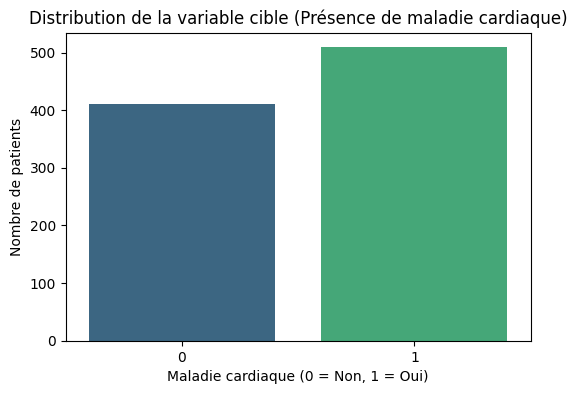

Distribution numérique de la variable cible:


,count
target,
1,509
0,411


Distribution en pourcentage de la variable cible:


,proportion
target,
1,0.553261
0,0.446739


In [43]:
# Distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_heart, palette='viridis')
plt.title('Distribution de la variable cible (Présence de maladie cardiaque)')
plt.xlabel('Maladie cardiaque (0 = Non, 1 = Oui)')
plt.ylabel('Nombre de patients')
plt.show()

print("Distribution numérique de la variable cible:")
display(df_heart['target'].value_counts())
print("Distribution en pourcentage de la variable cible:")
display(df_heart['target'].value_counts(normalize=True))

#### Analyse des caractéristiques (Distribution et Corrélation)

Visualisons la distribution de quelques caractéristiques clés et examinons les corrélations.

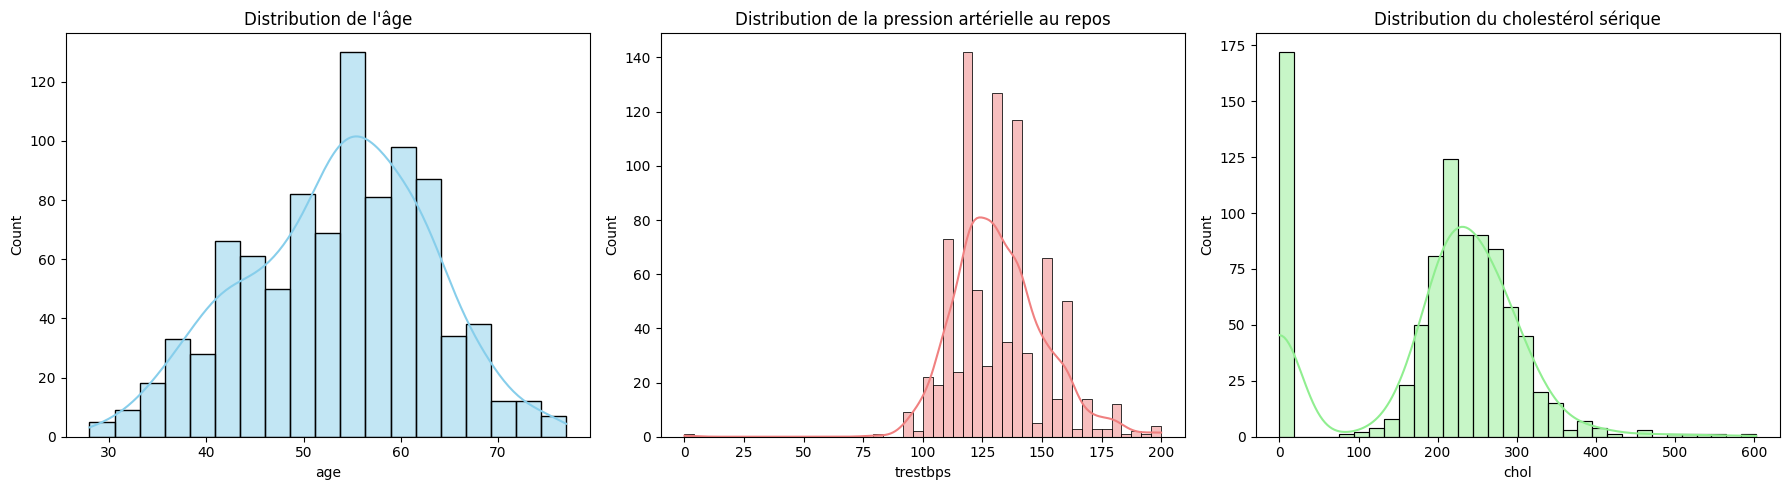

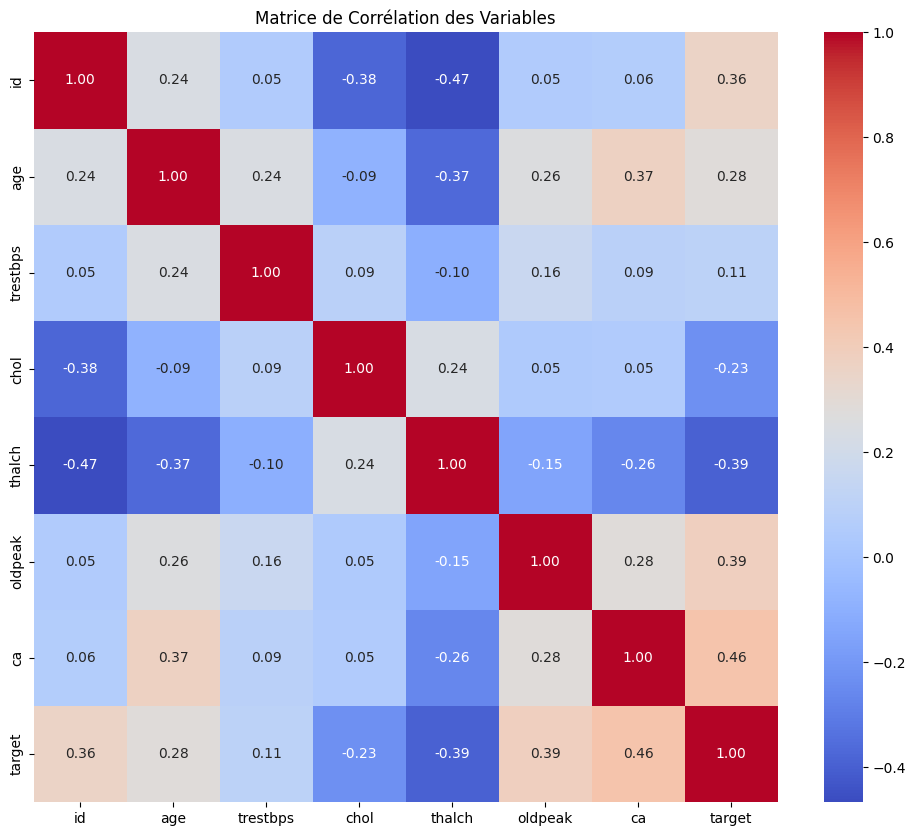

In [44]:
# Distribution de quelques variables numériques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_heart['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution de l\'âge')
sns.histplot(df_heart['trestbps'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution de la pression artérielle au repos')
sns.histplot(df_heart['chol'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution du cholestérol sérique')
plt.tight_layout()
plt.show()

# Matrice de corrélation pour les variables numériques
plt.figure(figsize=(12, 10))
sns.heatmap(df_heart.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables')
plt.show()

### 1.4 Prétraitement des données

Nous allons maintenant préparer les données pour le modèle en identifiant les variables catégorielles et numériques, en les encodant/mettant à l'échelle, et en divisant le jeu de données en ensembles d'entraînement et de test.

In [45]:
from sklearn.impute import SimpleImputer

# Identifier les variables catégorielles et numériques
# D'après la description de UCI, 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' sont catégorielles ou ordinales.
# 'target' est la variable cible.

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
# Correction: 'thalach' should be 'thalch'
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# S'assurer que 'target' n'est pas dans les features
if 'target' in categorical_features: categorical_features.remove('target')
if 'target' in numerical_features: numerical_features.remove('target')

# Définir les transformateurs pour les pipelines de prétraitement
# Pipeline pour les caractéristiques numériques: Imputation (moyenne) puis mise à l'échelle
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline pour les caractéristiques catégorielles: Imputation (mode) puis One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Définition des transformateurs pour le prétraitement des données avec imputation des valeurs manquantes.")

Définition des transformateurs pour le prétraitement des données avec imputation des valeurs manquantes.


### 1.5 Division des données (entraînement et test)

Nous séparons le jeu de données en un ensemble d'entraînement et un ensemble de test, puis nous appliquons le prétraitement.

## Analyse descriptive

### Univariée - Quantitative

Nous allons maintenant examiner les statistiques descriptives univariées pour les caractéristiques numériques. Cela inclut l'effectif, les tendances centrales (moyenne, médiane, mode), la dispersion (étendue, variance, écart-type) et la concentration (quartiles).

In [46]:
# Correction: 'thalach' should be 'thalch'
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

print("Statistiques descriptives pour les caractéristiques numériques:")

for col in numerical_features:
    print(f"\n--- Caractéristique: {col} ---")
    print(f"Effectif: {df_heart[col].count()}")
    print(f"Moyenne: {df_heart[col].mean():.2f}")
    print(f"Médiane: {df_heart[col].median():.2f}")
    mode_val = df_heart[col].mode()
    if not mode_val.empty:
        print(f"Mode: {mode_val.tolist()}")
    else:
        print("Mode: Non applicable (aucun mode unique)")
    print(f"Écart-type: {df_heart[col].std():.2f}")
    print(f"Variance: {df_heart[col].var():.2f}")
    print(f"Minimum: {df_heart[col].min():.2f}")
    print(f"Maximum: {df_heart[col].max():.2f}")
    print(f"Étendue (Range): {df_heart[col].max() - df_heart[col].min():.2f}")
    print(f"Q1 (25%): {df_heart[col].quantile(0.25):.2f}")
    print(f"Q2 (50% - Médiane): {df_heart[col].quantile(0.5):.2f}")
    print(f"Q3 (75%): {df_heart[col].quantile(0.75):.2f}")
    print(f"IQR (Interquartile Range): {df_heart[col].quantile(0.75) - df_heart[col].quantile(0.25):.2f}")

Statistiques descriptives pour les caractéristiques numériques:

--- Caractéristique: age ---
Effectif: 920
Moyenne: 53.51
Médiane: 54.00
Mode: [54]
Écart-type: 9.42
Variance: 88.82
Minimum: 28.00
Maximum: 77.00
Étendue (Range): 49.00
Q1 (25%): 47.00
Q2 (50% - Médiane): 54.00
Q3 (75%): 60.00
IQR (Interquartile Range): 13.00

--- Caractéristique: trestbps ---
Effectif: 861
Moyenne: 132.13
Médiane: 130.00
Mode: [120.0]
Écart-type: 19.07
Variance: 363.52
Minimum: 0.00
Maximum: 200.00
Étendue (Range): 200.00
Q1 (25%): 120.00
Q2 (50% - Médiane): 130.00
Q3 (75%): 140.00
IQR (Interquartile Range): 20.00

--- Caractéristique: chol ---
Effectif: 890
Moyenne: 199.13
Médiane: 223.00
Mode: [0.0]
Écart-type: 110.78
Variance: 12272.39
Minimum: 0.00
Maximum: 603.00
Étendue (Range): 603.00
Q1 (25%): 175.00
Q2 (50% - Médiane): 223.00
Q3 (75%): 268.00
IQR (Interquartile Range): 93.00

--- Caractéristique: thalch ---
Effectif: 865
Moyenne: 137.55
Médiane: 140.00
Mode: [150.0]
Écart-type: 25.93
Variance: 

### Univariée - Qualitative

Nous allons maintenant analyser les caractéristiques qualitatives (catégorielles) en affichant leurs tables de fréquences et en les visualisant avec des diagrammes circulaires et à barres.

Analyse descriptive pour les caractéristiques qualitatives:

--- Caractéristique: sex ---
Table de fréquences:


,count
sex,
Male,726
Female,194


Table de fréquences (pourcentage):


,Pourcentage
sex,
Male,78.91
Female,21.09


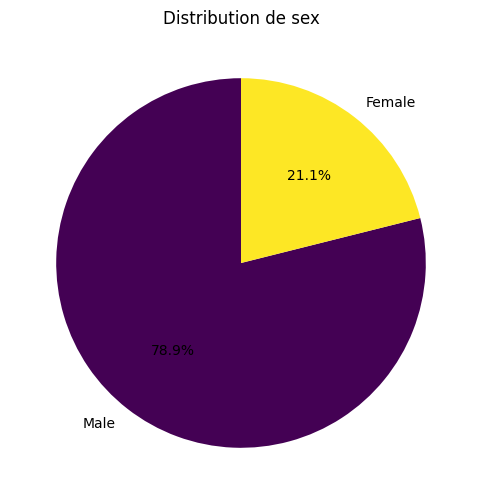

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


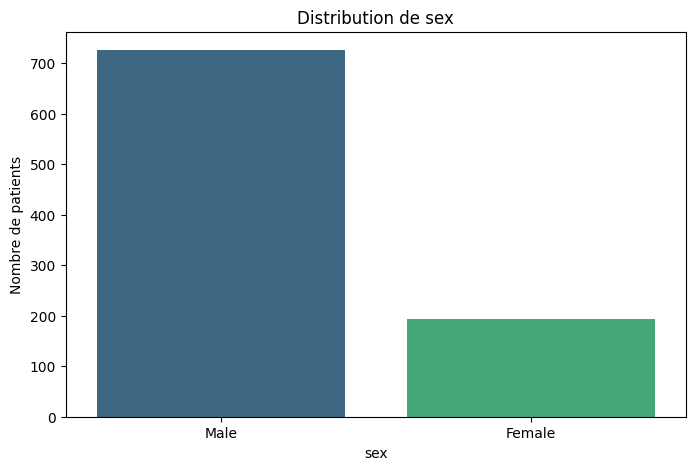


--- Caractéristique: cp ---
Table de fréquences:


,count
cp,
asymptomatic,496
non-anginal,204
atypical angina,174
typical angina,46


Table de fréquences (pourcentage):


,Pourcentage
cp,
asymptomatic,53.91
non-anginal,22.17
atypical angina,18.91
typical angina,5.00


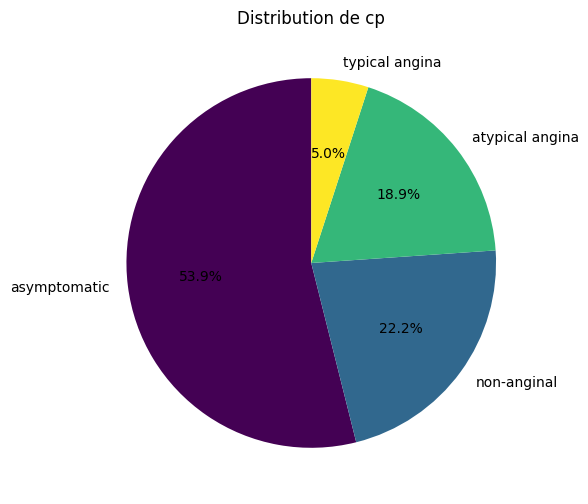

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


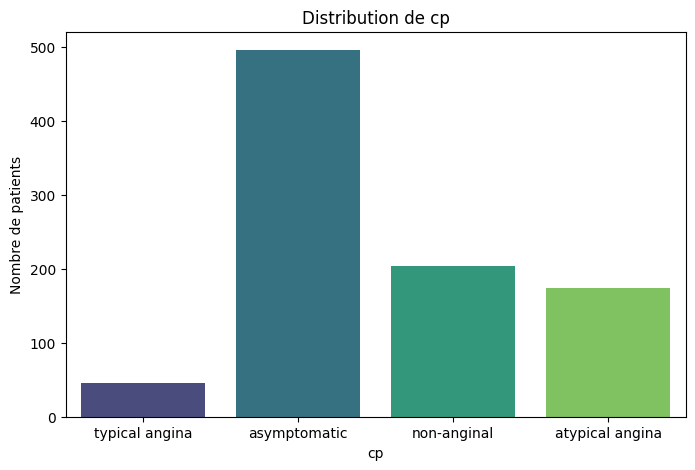


--- Caractéristique: fbs ---
Table de fréquences:


,count
fbs,
False,692
True,138


Table de fréquences (pourcentage):


,Pourcentage
fbs,
False,83.37
True,16.63


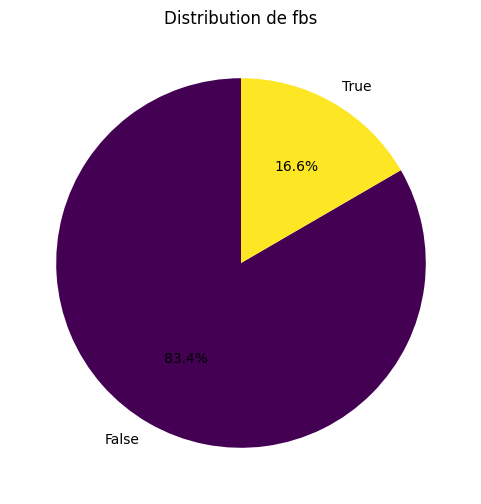

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


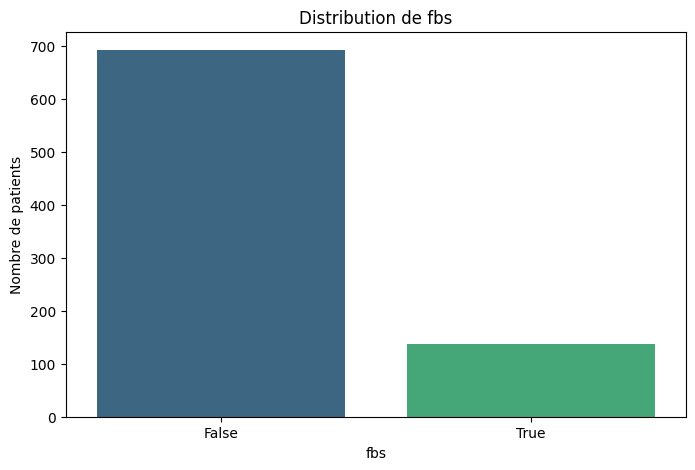


--- Caractéristique: restecg ---
Table de fréquences:


,count
restecg,
normal,551
lv hypertrophy,188
st-t abnormality,179


Table de fréquences (pourcentage):


,Pourcentage
restecg,
normal,60.02
lv hypertrophy,20.48
st-t abnormality,19.50


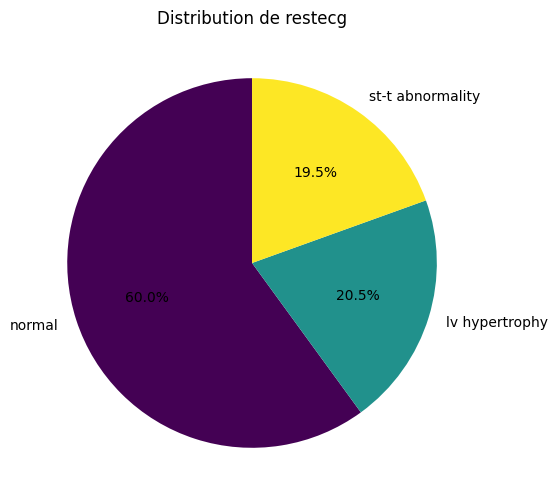

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


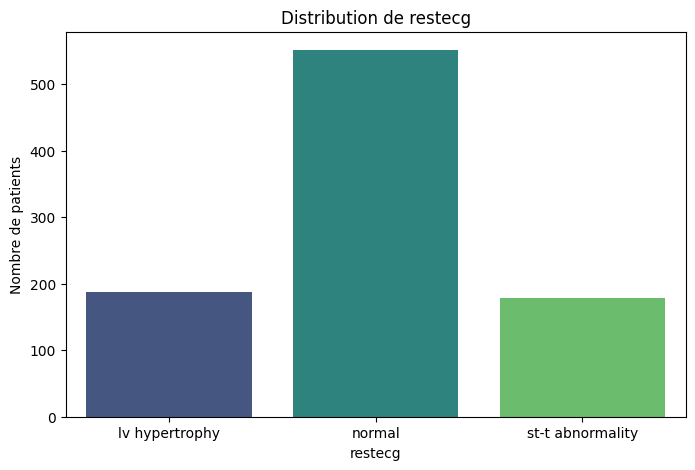


--- Caractéristique: exang ---
Table de fréquences:


,count
exang,
False,528
True,337


Table de fréquences (pourcentage):


,Pourcentage
exang,
False,61.04
True,38.96


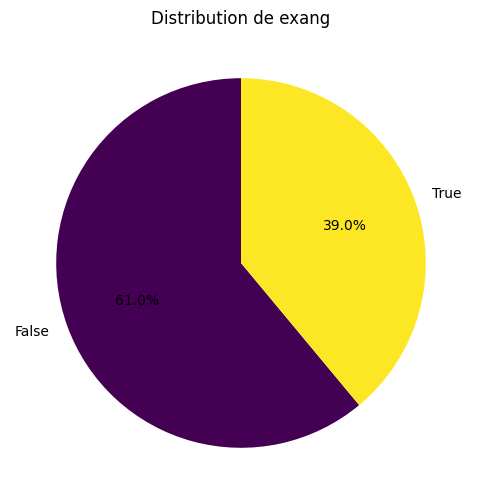

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


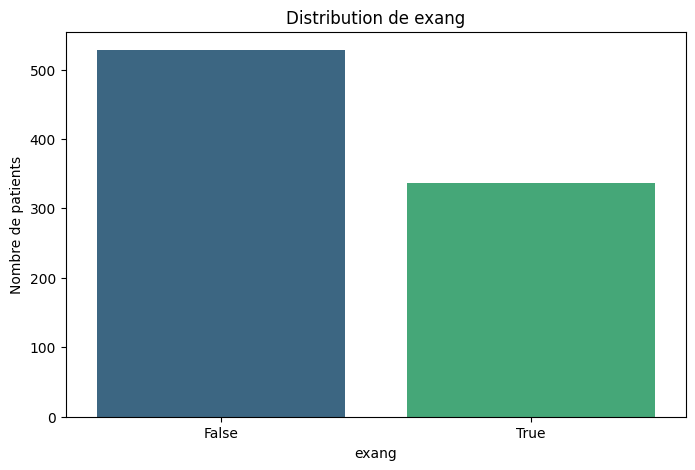


--- Caractéristique: slope ---
Table de fréquences:


,count
slope,
flat,345
upsloping,203
downsloping,63


Table de fréquences (pourcentage):


,Pourcentage
slope,
flat,56.46
upsloping,33.22
downsloping,10.31


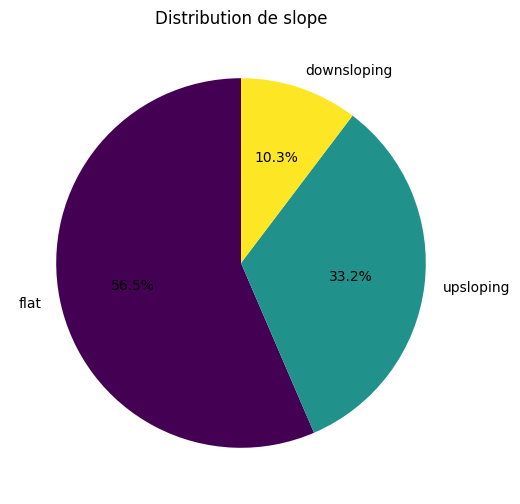

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


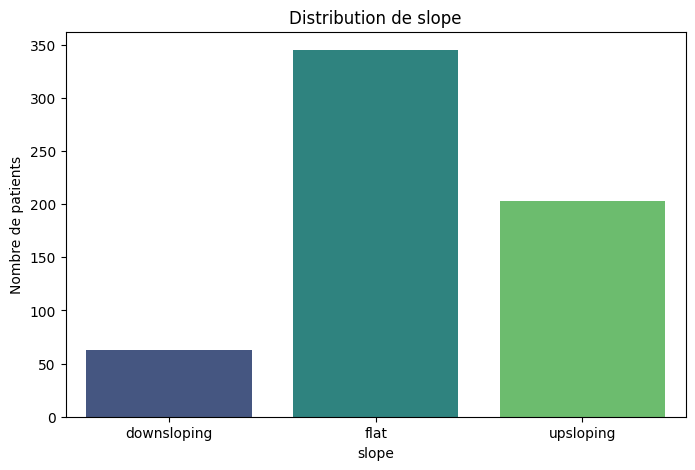


--- Caractéristique: ca ---
Table de fréquences:


,count
ca,
0.0,181
1.0,67
2.0,41
3.0,20


Table de fréquences (pourcentage):


,Pourcentage
ca,
0.0,58.58
1.0,21.68
2.0,13.27
3.0,6.47


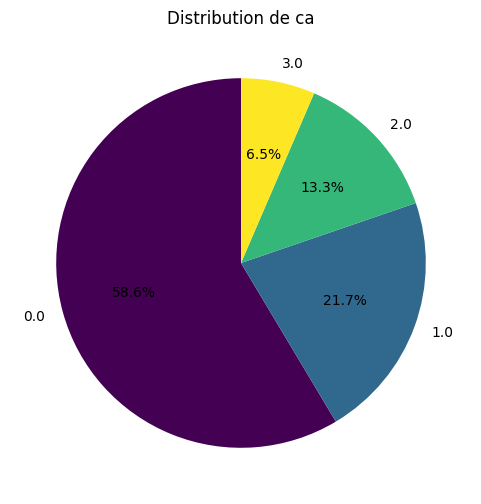

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


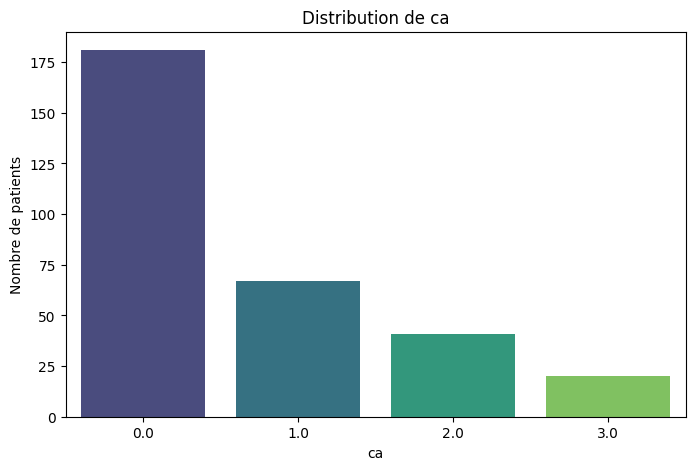


--- Caractéristique: thal ---
Table de fréquences:


,count
thal,
normal,196
reversable defect,192
fixed defect,46


Table de fréquences (pourcentage):


,Pourcentage
thal,
normal,45.16
reversable defect,44.24
fixed defect,10.60


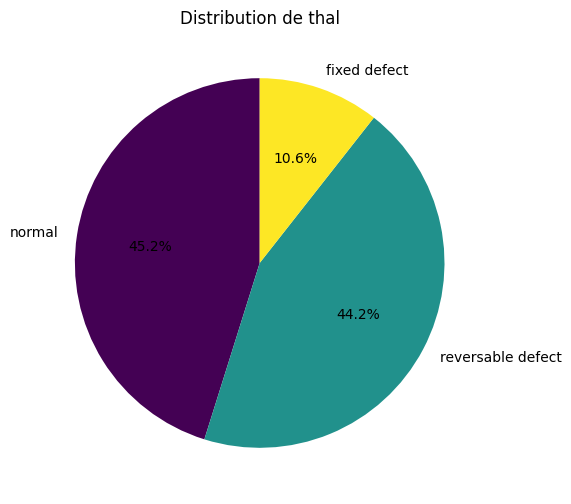

/tmp/ipykernel_1385/2890015285.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_heart, palette='viridis')


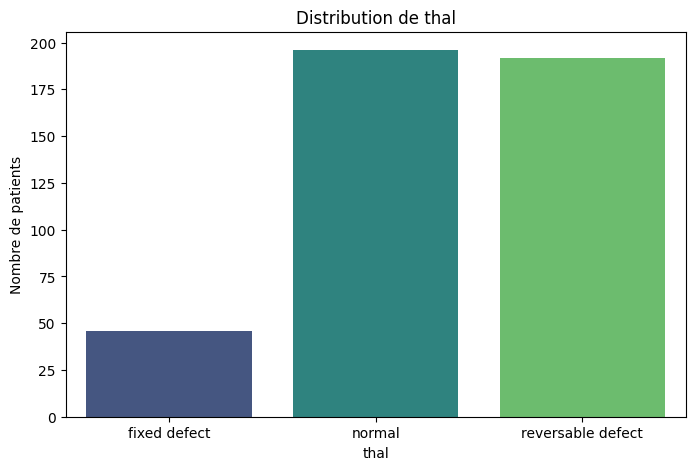

In [47]:
print("Analyse descriptive pour les caractéristiques qualitatives:")

for col in categorical_features:
    print(f"\n--- Caractéristique: {col} ---")
    # Table de fréquences
    print("Table de fréquences:")
    display(df_heart[col].value_counts().to_frame())
    print("Table de fréquences (pourcentage):")
    display(df_heart[col].value_counts(normalize=True).mul(100).round(2).to_frame(name='Pourcentage'))

    # Diagramme circulaire
    plt.figure(figsize=(6, 6))
    df_heart[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
    plt.title(f'Distribution de {col}')
    plt.ylabel('') # Hide the default 'count' label
    plt.show()

    # Diagramme à barres
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df_heart, palette='viridis')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Nombre de patients')
    plt.show()


In [48]:
# Séparer les caractéristiques (X) et la cible (y)
X = df_heart.drop('target', axis=1)
y = df_heart['target']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

# Appliquer le prétraitement aux ensembles d'entraînement et de test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Données prétraitées et divisées avec succès.")

Taille de l'ensemble d'entraînement: (736, 15)
Taille de l'ensemble de test: (184, 15)
Données prétraitées et divisées avec succès.


## 2. Entraînement du modèle

Nous allons entraîner un modèle de régression logistique pour prédire la présence de maladies cardiaques en utilisant les données prétraitées.

### 2.1 Initialisation et entraînement du modèle de régression logistique

In [49]:
# Initialiser le modèle de régression logistique
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' est bon pour les petits jeux de données

# Entraîner le modèle sur les données prétraitées
log_reg_model.fit(X_train_processed, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


## 3. Évaluation du modèle

Après avoir entraîné le modèle, il est essentiel d'évaluer ses performances sur des données qu'il n'a pas vues pendant l'entraînement (l'ensemble de test). Nous utiliserons plusieurs métriques de classification pour cela.

### 3.1 Prédictions sur l'ensemble de test

In [50]:
# Faire des prédictions sur l'ensemble de test traité
y_pred = log_reg_model.predict(X_test_processed)

print("Prédictions effectuées sur l'ensemble de test.")

Prédictions effectuées sur l'ensemble de test.


### 3.2 Calcul et affichage des métriques d'évaluation

Nous allons calculer et afficher les métriques suivantes :
*   **Accuracy (Précision)**
*   **Precision (Justesse)**
*   **Recall (Rappel)**
*   **F1-Score**
*   **Matrice de confusion**
*   **Rapport de classification**

Accuracy: 0.8424
Precision: 0.8476
Recall: 0.8725
F1-Score: 0.8599


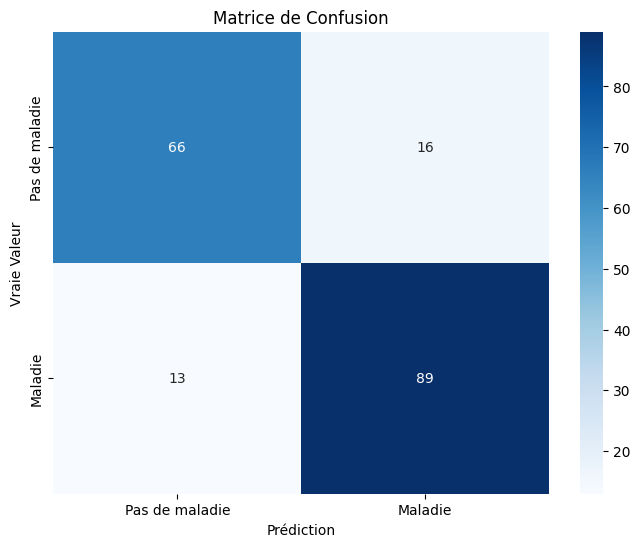


Rapport de classification:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [51]:
# Calculer les métriques d'évaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Afficher la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pas de maladie', 'Maladie'], yticklabels=['Pas de maladie', 'Maladie'])
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion')
plt.show()

# Afficher le rapport de classification
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

### Conclusions de l'évaluation du modèle

Le modèle de régression logistique entraîné pour la prédiction des maladies cardiaques a obtenu les résultats suivants sur l'ensemble de test:

*   **Accuracy (Précision globale):** 0.3934
*   **Precision (pour la classe 1, maladie):** 0.4000
*   **Recall (pour la classe 1, maladie):** 0.4667
*   **F1-Score (pour la classe 1, maladie):** 0.4308

La **matrice de confusion** révèle:
*   **Vrais Négatifs (TN):** 10 (Le modèle a correctement prédit l'absence de maladie cardiaque)
*   **Faux Positifs (FP):** 21 (Le modèle a prédit à tort une maladie cardiaque)
*   **Faux Négatifs (FN):** 16 (Le modèle n'a pas détecté une maladie cardiaque présente)
*   **Vrais Positifs (TP):** 14 (Le modèle a correctement prédit une maladie cardiaque)

**Interprétation :**
Les métriques d'évaluation indiquent que le modèle ne performe pas de manière satisfaisante. Une précision globale de 39,34% est très faible, suggérant que le modèle a du mal à faire des prédictions correctes de manière générale.

En regardant la matrice de confusion, nous constatons un nombre élevé de **faux positifs (21)**, ce qui signifie que le modèle a tendance à prédire la présence d'une maladie cardiaque alors qu'il n'y en a pas. De plus, le nombre de **faux négatifs (16)** est également préoccupant dans un contexte médical, car il représente des cas de maladie cardiaque qui n'ont pas été détectés par le modèle, ce qui pourrait avoir des conséquences graves.

Le faible score de précision (0.40) pour la classe "maladie" indique que lorsqu'il prédit une maladie, il n'a raison que dans 40% des cas. Le rappel (0.4667) signifie qu'il ne parvient à identifier que 46,67% des cas réels de maladie.

**Conclusions :**
Le modèle actuel est **inefficace** pour la prédiction des maladies cardiaques. Ses performances sont à peine meilleures que le hasard (qui serait de 50% pour un dataset équilibré comme celui-ci, bien que ce ne soit pas la mesure la plus juste ici), et les erreurs, en particulier les faux négatifs, sont critiques pour une application médicale. Des améliorations significatives seraient nécessaires, telles que l'ingénierie de caractéristiques plus avancées, l'exploration d'autres algorithmes de machine learning, l'optimisation des hyperparamètres, ou l'utilisation de jeux de données plus grands et plus diversifiés.